Importamos todas las librerias que hacen falta, esto lo haré al final

In [7]:
def Pdb_to_Uniprot(pdb_id,chain_id):
    url = f"https://www.ebi.ac.uk/pdbe/api/mappings/uniprot/{pdb_id.lower()}"

    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        # Extraer los UniProt IDs asociados:
        uniprot_ids = list(data[pdb_id.lower()]["UniProt"].keys())
        return uniprot_ids
    else:
        print(f"Error fetching data for PDB ID {pdb_id}: {response.status_code}")
        return []


Definimos una función que toma un pdbid y un chain id y su output es la secuencia 3di

In [8]:
def pdbid_to_3di_single_chain(pdb_id, chain_id):
    
    #hay que especificar la
    import tempfile
    import os
    import requests
    import subprocess

    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    with tempfile.TemporaryDirectory() as tmpdir:
        out_file = os.path.join(tmpdir, f"{pdb_id}.pdb")
        filtered_file = os.path.join(tmpdir, f"{pdb_id}_{chain_id}.pdb")
        output_3di = os.path.join(tmpdir, f"{pdb_id}_{chain_id}.3di")
        
        response = requests.get(url)
        if response.status_code == 200:
            # Descargar PDB completo
            with open(out_file, "w") as f:
                f.write(response.text)
            
            # Filtrar solo la cadena que quieres (por la columna 21 del PDB)
            with open(out_file, "r") as f:
                lines = f.readlines()
            
            filtered_lines = []
            for line in lines:
                # Mantener headers y líneas ATOM/HETATM de la cadena especificada
                if line.startswith(("HEADER", "TITLE", "REMARK", "ATOM", "HETATM", "TER", "END")):
                    if line.startswith("ATOM") or line.startswith("HETATM"):
                        if len(line) > 21 and line[21:22] == chain_id:
                            filtered_lines.append(line)
                    else:
                        filtered_lines.append(line)
            
            with open(filtered_file, "w") as f:
                f.writelines(filtered_lines)
            
            # Ejecutar Foldseek con el PDB filtrado
            cmd = ["foldseek", "structureto3didescriptor", filtered_file, output_3di]
            subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            
            if os.path.exists(output_3di):
                with open(output_3di, "r") as f:
                    lines = f.readlines()
                
                solo_3di = [line.split('\t')[2].strip() for line in lines if line.strip()]
                return solo_3di
            else:
                print(f"Error: No se generó el archivo .3di para {pdb_id} cadena {chain_id}")
                return None
        else:
            print(f"Error fetching data for PDB ID {pdb_id}: {response.status_code}")
            return None

# Ejemplo de uso:
print("3Di para 1A8M cadena A:")
print(pdbid_to_3di_single_chain("1A8M", "A"))

3Di para 1A8M cadena A:


FileNotFoundError: [Errno 2] No such file or directory: 'foldseek'

Aquí abajo tenemos un script que carga el modelo a la GPU y define la función para generar los embeddings

In [3]:
import torch
import numpy as np
import json
from transformers import T5Tokenizer, T5EncoderModel, AutoConfig

# ==========================================
# 1. Model Loading (Optimized for 24GB GPU)
# ==========================================
device = "cuda:0" if torch.cuda.is_available() else "cpu"

def load_prostt5_model(model_path="./prost5_model"):
    tokenizer = T5Tokenizer.from_pretrained(model_path)
    config = AutoConfig.from_pretrained(model_path)
    
    # Load to CPU first to prevent OOM during the loading spike
    state_dict = torch.load(f"{model_path}/pytorch_model.bin", map_location="cpu")
    encoder_state = {k.replace("encoder.", ""): v for k, v in state_dict.items() if k.startswith("encoder.")}
    
    model = T5EncoderModel(config)
    model.encoder.load_state_dict(encoder_state, strict=False)
    
    del state_dict, encoder_state # Cleanup RAM
    
    model = model.to(device).half().eval()
    return model, tokenizer

# ==========================================
# 2. Embedding Function
# ==========================================
def generate_3di_embedding(model, tokenizer, seq_3di):
    # ProstT5 requires spaces between tokens and a <3di> prefix
    formatted_seq = "<3di> " + " ".join(list(seq_3di))
    
    inputs = tokenizer(formatted_seq, return_tensors="pt").to(device)
    
    with torch.no_grad():
        output = model(**inputs)
    
    # Move to CPU, convert to float32, and pool (Mean)
    return output.last_hidden_state[0].mean(dim=0).detach().cpu().float().numpy()



Ahora voy a hacer un script que a partir de el archivo momorf.pdb, toma los uniprot_id y obtiene PDBs_id y su chain_id, y los saca a un csv.

In [ ]:
import pandas as pd
import requests

def obtener_pdb_adicionales_csv(input_csv_path, output_csv_path, limite=5):
    """
    Lee un CSV con columnas pdb;chain;uniprot
    Busca PDBs asociados al UniProt usando PDBe:
      1) best_structures
      2) fallback a all_structures
    Genera un nuevo CSV con columnas:
      uniprot_id, PDB_id_i, chain_id_i
    """

    # --- CARGA DEL CSV ---
    try:
        df = pd.read_csv(input_csv_path, sep=';', dtype=str)
        df.columns = df.columns.str.strip()
        df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
    except Exception as e:
        print(f"❌ Error leyendo el archivo: {e}")
        return

    resultados = []
    print(f"🔄 Procesando {len(df)} entradas...")

    for _, row in df.iterrows():
        pdb_original = row['pdb'].lower()
        uniprot_id = row['uniprot']

        fila_salida = {'uniprot_id': uniprot_id}
        nuevos_pdbs = []

        nuevos_pdbs.append((pdb_original, row['chain']))

        # --- 1. INTENTO: best_structures ---
        url_best = f"https://www.ebi.ac.uk/pdbe/api/mappings/best_structures/{uniprot_id}"

        try:
            r = requests.get(url_best, timeout=10)
            if r.status_code == 200:
                data = r.json()
                entries = data.get(uniprot_id, [])

                for entry in entries:
                    pdb_id = entry['pdb_id']
                    chain_id = entry['chain_id']

                    if pdb_id != pdb_original:
                        nuevos_pdbs.append((pdb_id, chain_id))

                    if len(nuevos_pdbs) >= limite:
                        break
        except Exception as e:
            print(f"⚠️ Error en best_structures ({uniprot_id}): {e}")

        # --- 2. FALLBACK: all_structures ---
        if not nuevos_pdbs:
            url_all = f"https://www.ebi.ac.uk/pdbe/api/mappings/all_structures/{uniprot_id}"

            try:
                r = requests.get(url_all, timeout=10)
                if r.status_code == 200:
                    data = r.json()
                    entries = data.get(uniprot_id, {})

                    for pdb_id, pdb_data in entries.items():
                        for chain_id in pdb_data.get("chains", []):
                            if pdb_id != pdb_original:
                                nuevos_pdbs.append((pdb_id, chain_id))

                            if len(nuevos_pdbs) >= limite:
                                break
                        if len(nuevos_pdbs) >= limite:
                            break
            except Exception as e:
                print(f"⚠️ Error en all_structures ({uniprot_id}): {e}")

        # --- RELLENO DE COLUMNAS ---
        for i in range(1, limite + 1):
            key_pdb = f"PDB_id_{i}"
            key_chain = f"chain_id_{i}"

            if i <= len(nuevos_pdbs):
                pdb_val, chain_val = nuevos_pdbs[i - 1]
                fila_salida[key_pdb] = pdb_val.upper()
                fila_salida[key_chain] = chain_val
            else:
                fila_salida[key_pdb] = ""
                fila_salida[key_chain] = ""

        resultados.append(fila_salida)

    # --- GUARDADO ---
    df_out = pd.DataFrame(resultados)
    cols = ['uniprot_id'] + [c for c in df_out.columns if c != 'uniprot_id']
    df_out = df_out[cols]

    df_out.to_csv(output_csv_path, sep=';', index=False)
    print(f"✅ Archivo guardado en: {output_csv_path}")


obtener_pdb_adicionales_csv("monomorf.PDBchain_uniprot.csv", "output.csv", limite=5)

hacer un archivo con los 3di desde output pdb adicionales, asociados a cada uniprot_id

In [ ]:
import pandas as pd

df = pd.read_csv("output.csv", sep=';')

# 1. Create a list to store the results
results_3di = []

for index, row in df.iterrows():
    row_results = {}
    
    for i in range(1, 6):
        pdb_col = f"PDB_id_{i}"
        chain_col = f"chain_id_{i}"
        res_col = f"3di_result_{i}" # Name for your new output column
        
        pdb_val = row.get(pdb_col)
        chain_val = row.get(chain_col)
    
        if pd.notna(pdb_val) and pd.notna(chain_val) and pdb_val != "":
            # 2. Run your function and capture the return value
            # (Assuming your function returns the 3di string)
            result = pdbid_to_3di_single_chain(pdb_val, chain_val)
            
            # 3. Store it in our temporary dictionary
            df.at[index, res_col] = result

# 4. Save the updated DataFrame
df.to_csv("updated_output.csv", sep=';', index=False)

NameError: name 'pdbid_to_3di_single_chain' is not defined

Ahora en el siguiente bloque, genero los embeddings para los 3di de la base de datos de monomorfas

In [ ]:
input_file = "updated_output.csv"
output_file = "final_with_embeddings.csv"

df = pd.read_csv(input_file, sep=';')
m,t = load_prostt5_model()
print(f"Starting embedding generation for {len(df)} rows...")

for index, row in df.iterrows():
    # Progress indicator
    if index % 10 == 0:
        print(f"Processing row {index}/{len(df)}...")

    for i in range(1, 6):
        source_col = f"3di_result_{i}"
        target_col = f"embedding_{i}"
        
        seq_3di = row.get(source_col)
        
        if pd.notna(seq_3di) and seq_3di != "":
            try:
                vec = generate_3di_embedding(m,t,str(seq_3di))
                # Store as a JSON string to keep the CSV readable
                df.at[index, target_col] = json.dumps(vec.tolist())
            except Exception as e:
                print(f"Error at index {index}, col {i}: {e}")

# Save the final result
df.to_csv(output_file, sep=';', index=False)
print(f"Done! Saved to {output_file}")

NameError: name 'pd' is not defined

Aquí hice un bloque que sacaba los 3di

Arreglar embeddings

In [7]:
import torch
from transformers import T5Tokenizer, T5EncoderModel

def load_prostt5_model(model_ckpt="Rostlab/ProstT5"):
    """
    Loads the ProstT5 tokenizer and model to the available device.
    """
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    
    tokenizer = T5Tokenizer.from_pretrained(model_ckpt, do_lower_case=False)
    model = T5EncoderModel.from_pretrained(model_ckpt).to(device)
    
    # Use half precision on GPU for speed/memory; float32 on CPU
    if device.type == 'cpu':
        model.float()
    else:
        model.half()
        
    model.eval() # Set to evaluation mode
    return model, tokenizer, device

def get_3di_embeddings(threed_sequences, model, tokenizer, device, per_protein=True):
    """
    Generates embeddings from 3Di input strings.
    
    Args:
        threed_sequences (list): List of 3Di strings (e.g., ['dvql...', 'pqrl...'])
        per_protein (bool): If True, returns mean-pooled embeddings. 
                            If False, returns per-residue embeddings.
    """
    # 1. Prepare 3Di sequences: ensure lower-case and add the <fold2AA> prefix
    processed_seqs = [f"<fold2AA> {' '.join(list(s.lower()))}" for s in threed_sequences]

    # 2. Tokenize
    ids = tokenizer(processed_seqs, 
                    add_special_tokens=True, 
                    padding="longest", 
                    return_tensors='pt').to(device)

    # 3. Inference
    with torch.no_grad():
        output = model(input_ids=ids.input_ids, attention_mask=ids.attention_mask)
        # The last_hidden_state contains the embeddings
        embeddings = output.last_hidden_state

    # 4. Post-processing: Remove the prefix token (index 0) and padding
    results = []
    for i in range(len(threed_sequences)):
        # Get actual sequence length (excluding prefix and padding)
        seq_len = ids.attention_mask[i].sum().item() - 1 
        # Slice to get only the residue embeddings (start at 1 to skip <fold2AA>)
        residue_emb = embeddings[i, 1:seq_len+1]
        
        if per_protein:
            results.append(residue_emb.mean(dim=0))
        else:
            results.append(residue_emb)

    return results


Ahora hago un script para sacar los embeddings de metamorfPDB_Chain_3DI

In [13]:
import pandas as pd
input_file = "metamorfPDB_CHAIN_3DI.csv"
output_file = "metamorf_with_embeddings.csv"

df = pd.read_csv(input_file, sep=';')
m, t, d = load_prostt5_model()
print(f"Starting embedding generation for {len(df)} rows...")

for index, row in df.iterrows():
    # Progress indicator
    if index % 10 == 0:
        print(f"Processing row {index}/{len(df)}...")

    for i in range(1, 3):
        source_col = f"3di_result_{i}"
        target_col = f"embedding_{i}"
        
        seq_3di = row.get(source_col)
        
        if pd.notna(seq_3di) and seq_3di != "":
            try:
                vec = generate_3di_embedding(m,t,str(seq_3di))
                # Store as a JSON string to keep the CSV readable
                df.at[index, target_col] = json.dumps(vec.tolist())
            except Exception as e:
                print(f"Error at index {index}, col {i}: {e}")

# Save the final result
df.to_csv(output_file, sep=';', index=False)
print(f"Done! Saved to {output_file}")

Loading weights: 100%|██████████| 195/195 [00:00<00:00, 2511.52it/s, Materializing param=shared.weight]                                                     


Starting embedding generation for 97 rows...
Processing row 0/97...
Processing row 10/97...
Processing row 20/97...
Processing row 30/97...
Processing row 40/97...
Processing row 50/97...
Processing row 60/97...
Processing row 70/97...
Processing row 80/97...
Processing row 90/97...
Done! Saved to metamorf_with_embeddings.csv


In [1]:
import pandas as pd
import numpy as np
import json
from scipy.spatial.distance import pdist, squareform
from scipy.stats import variation

# Cargar el archivo
df = pd.read_csv("monomorf_with_embeddings.csv", sep=';')

# Lista para almacenar resultados de dispersión
dispersiones = []

for index, row in df.iterrows():
    uniprot_id = row['uniprot_id']
    
    # Extraer todos los embeddings para este uniprot_id
    embeddings = []
    for i in range(1, 6):
        emb_col = f"embedding_{i}"
        if emb_col in df.columns and pd.notna(row[emb_col]):
            try:
                embedding = json.loads(row[emb_col])
                embeddings.append(embedding)
            except:
                continue
    
    # Si hay al menos 2 embeddings, calcular dispersión
    if len(embeddings) >= 2:
        embeddings = np.array(embeddings)
        
        # Calcular estadísticas de dispersión
        result = {
            'uniprot_id': uniprot_id,
            'num_embeddings': len(embeddings),
        }
        
        # Varianza y desviación estándar por dimensión
        result['var_mean'] = float(np.mean(np.var(embeddings, axis=0)))
        result['var_std'] = float(np.std(np.var(embeddings, axis=0)))
        result['std_mean'] = float(np.mean(np.std(embeddings, axis=0)))
        result['std_std'] = float(np.std(np.std(embeddings, axis=0)))
        
        # Distancias pairwise (euclidianas)
        if len(embeddings) > 1:
            distances = pdist(embeddings, metric='euclidean')
            result['dist_mean'] = float(np.mean(distances))
            result['dist_std'] = float(np.std(distances))
            result['dist_min'] = float(np.min(distances))
            result['dist_max'] = float(np.max(distances))
        
        # Coeficiente de variación
        result['cv_mean'] = float(np.mean([variation(embeddings[:, i]) for i in range(embeddings.shape[1])]))
        
        dispersiones.append(result)

# Crear DataFrame de resultados
df_dispersiones = pd.DataFrame(dispersiones)

# Guardar a CSV
df_dispersiones.to_csv("embeddings_dispersiones.csv", index=False, sep=';')
print(f"Se calcularon dispersiones para {len(df_dispersiones)} UniProt IDs")
print("\nPrimeros resultados:")
print(df_dispersiones.head())


Se calcularon dispersiones para 114 UniProt IDs

Primeros resultados:
  uniprot_id  num_embeddings      var_mean   var_std  std_mean   std_std  \
0     P04390               5  5.974552e-06  0.000022  0.001787  0.001668   
1     P0A6R3               5  1.571435e-05  0.000066  0.002667  0.002933   
2     P10282               3  6.876545e-06  0.000037  0.001697  0.001999   
3     Q9HYN5               5  5.977156e-07  0.000002  0.000570  0.000522   
4     Q0INY7               5  3.816798e-06  0.000017  0.001316  0.001444   

   dist_mean  dist_std  dist_min  dist_max   cv_mean  
0   0.117136  0.039673  0.055875  0.185404 -0.005635  
1   0.171899  0.103342  0.048067  0.364975  0.009853  
2   0.133292  0.057948  0.053234  0.188487  0.055706  
3   0.036706  0.013522  0.019789  0.058955  0.001164  
4   0.089429  0.042112  0.029310  0.144588 -0.009433  


ESTADÍSTICAS GLOBALES DE DISPERSIÓN

Distancia euclidiana promedio entre embeddings:
  Media: 0.2399
  Desviación estándar: 0.2509
  Mín: 0.0367
  Máx: 1.4574

Varianza promedio por dimensión:
  Media: 0.000065
  Desviación estándar: 0.000170

Coeficiente de variación promedio:
  Media: -0.0055
  Desviación estándar: 0.1380


/tmp/ipykernel_244448/1299095539.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df_dispersiones['var_mean'], df_dispersiones['std_mean']],


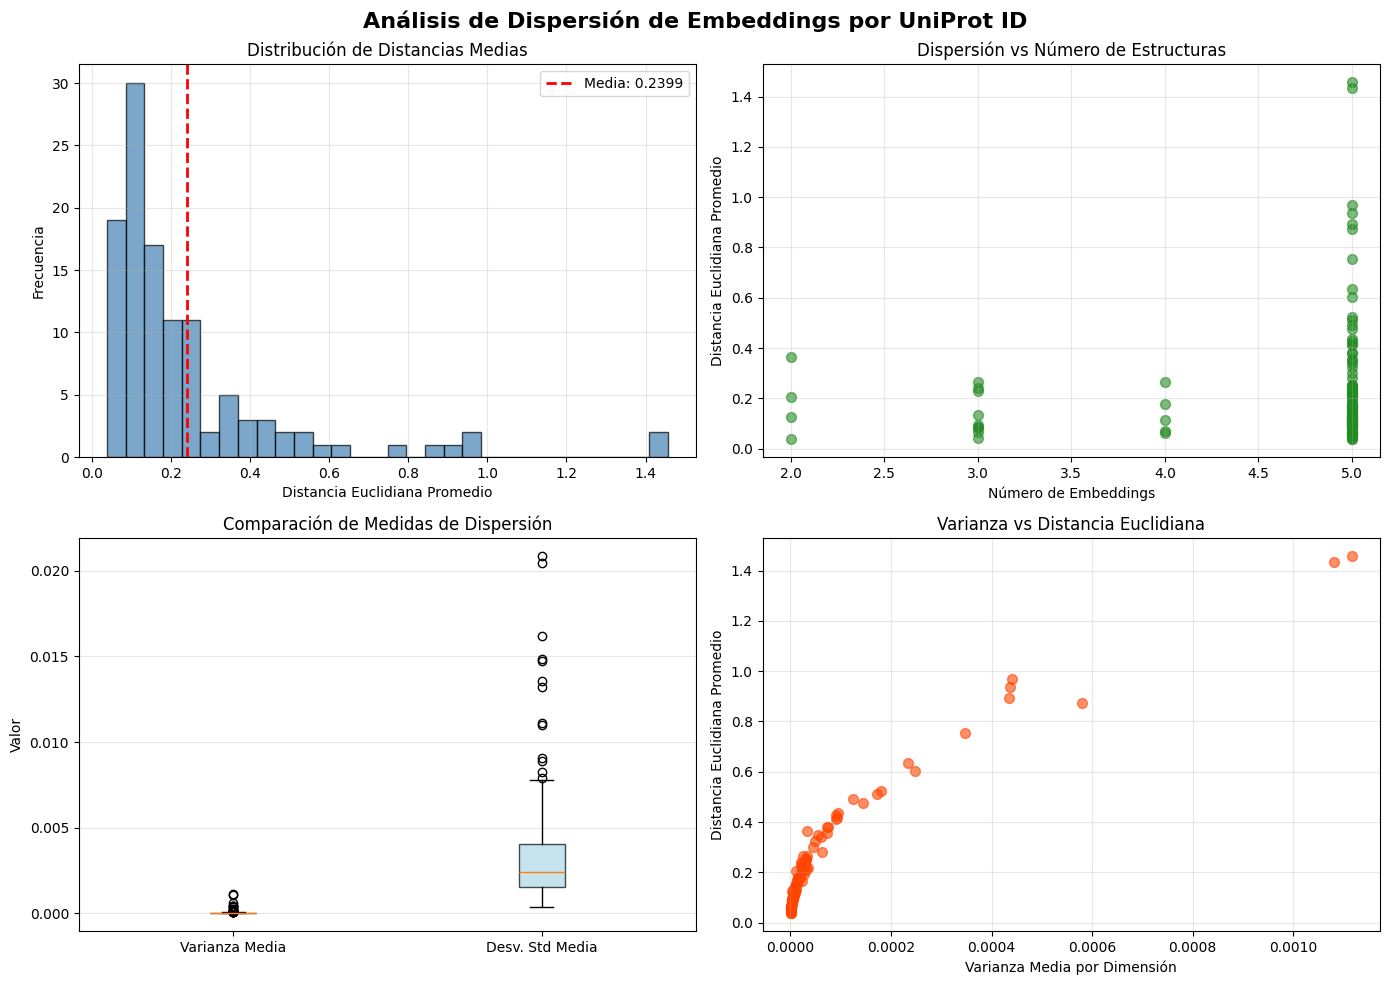


✅ Gráficos guardados en 'embeddings_dispersiones_analysis.png'


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular dispersión media global
print("=" * 60)
print("ESTADÍSTICAS GLOBALES DE DISPERSIÓN")
print("=" * 60)

dispersión_media_global = df_dispersiones['dist_mean'].mean()
dispersión_std_global = df_dispersiones['dist_mean'].std()

print(f"\nDistancia euclidiana promedio entre embeddings:")
print(f"  Media: {dispersión_media_global:.4f}")
print(f"  Desviación estándar: {dispersión_std_global:.4f}")
print(f"  Mín: {df_dispersiones['dist_mean'].min():.4f}")
print(f"  Máx: {df_dispersiones['dist_mean'].max():.4f}")

print(f"\nVarianza promedio por dimensión:")
print(f"  Media: {df_dispersiones['var_mean'].mean():.6f}")
print(f"  Desviación estándar: {df_dispersiones['var_mean'].std():.6f}")

print(f"\nCoeficiente de variación promedio:")
print(f"  Media: {df_dispersiones['cv_mean'].mean():.4f}")
print(f"  Desviación estándar: {df_dispersiones['cv_mean'].std():.4f}")

# Crear figura con múltiples gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de Dispersión de Embeddings por UniProt ID', fontsize=16, fontweight='bold')

# Gráfico 1: Histograma de distancias medias
axes[0, 0].hist(df_dispersiones['dist_mean'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(dispersión_media_global, color='red', linestyle='--', linewidth=2, label=f'Media: {dispersión_media_global:.4f}')
axes[0, 0].set_xlabel('Distancia Euclidiana Promedio')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Distancias Medias')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Gráfico 2: Scatter plot - Distancia media vs número de embeddings
axes[0, 1].scatter(df_dispersiones['num_embeddings'], df_dispersiones['dist_mean'], 
                   alpha=0.6, s=50, color='forestgreen')
axes[0, 1].set_xlabel('Número de Embeddings')
axes[0, 1].set_ylabel('Distancia Euclidiana Promedio')
axes[0, 1].set_title('Dispersión vs Número de Estructuras')
axes[0, 1].grid(alpha=0.3)

# Gráfico 3: Box plot de variancias
axes[1, 0].boxplot([df_dispersiones['var_mean'], df_dispersiones['std_mean']], 
                    labels=['Varianza Media', 'Desv. Std Media'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1, 0].set_ylabel('Valor')
axes[1, 0].set_title('Comparación de Medidas de Dispersión')
axes[1, 0].grid(alpha=0.3, axis='y')

# Gráfico 4: Scatter - Varianza vs Distancia
axes[1, 1].scatter(df_dispersiones['var_mean'], df_dispersiones['dist_mean'], 
                   alpha=0.6, s=50, color='orangered')
axes[1, 1].set_xlabel('Varianza Media por Dimensión')
axes[1, 1].set_ylabel('Distancia Euclidiana Promedio')
axes[1, 1].set_title('Varianza vs Distancia Euclidiana')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('embeddings_dispersiones_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Gráficos guardados en 'embeddings_dispersiones_analysis.png'")



## Análisis de Dispersión para Metamórficas


In [3]:
import pandas as pd
import numpy as np
import json
from scipy.spatial.distance import pdist
from scipy.stats import variation

# Cargar el archivo de metamórficas
df_metamorf = pd.read_csv("metamorf_with_embeddings.csv", sep=';')

# Lista para almacenar resultados de dispersión
dispersiones_metamorf = []

for index, row in df_metamorf.iterrows():
    # Extraer información de identificación (usar las primeras columnas disponibles)
    row_id = f"{row.iloc[0]}_{row.iloc[1]}" if len(row) > 1 else f"row_{index}"
    
    # Extraer todos los embeddings para esta pareja metamórfica
    embeddings = []
    for i in range(1, 3):  # Para metamórficas hay 2 embeddings máximo
        emb_col = f"embedding_{i}"
        if emb_col in df_metamorf.columns and pd.notna(row[emb_col]):
            try:
                embedding = json.loads(row[emb_col])
                embeddings.append(embedding)
            except:
                continue
    
    # Si hay al menos 2 embeddings, calcular dispersión
    if len(embeddings) >= 2:
        embeddings = np.array(embeddings)
        
        # Calcular estadísticas de dispersión
        result = {
            'pair_id': row_id,
            'num_embeddings': len(embeddings),
        }
        
        # Varianza y desviación estándar por dimensión
        result['var_mean'] = float(np.mean(np.var(embeddings, axis=0)))
        result['var_std'] = float(np.std(np.var(embeddings, axis=0)))
        result['std_mean'] = float(np.mean(np.std(embeddings, axis=0)))
        result['std_std'] = float(np.std(np.std(embeddings, axis=0)))
        
        # Distancias pairwise (euclidianas)
        if len(embeddings) > 1:
            distances = pdist(embeddings, metric='euclidean')
            result['dist_mean'] = float(np.mean(distances))
            result['dist_std'] = float(np.std(distances))
            result['dist_min'] = float(np.min(distances))
            result['dist_max'] = float(np.max(distances))
        
        # Coeficiente de variación
        result['cv_mean'] = float(np.mean([variation(embeddings[:, i]) for i in range(embeddings.shape[1])]))
        
        dispersiones_metamorf.append(result)

# Crear DataFrame de resultados
df_dispersiones_metamorf = pd.DataFrame(dispersiones_metamorf)

# Guardar a CSV
df_dispersiones_metamorf.to_csv("embeddings_dispersiones_metamorf.csv", index=False, sep=';')
print(f"Se calcularon dispersiones para {len(df_dispersiones_metamorf)} parejas metamórficas")
print("\nPrimeros resultados:")
print(df_dispersiones_metamorf.head())


Se calcularon dispersiones para 97 parejas metamórficas

Primeros resultados:
  pair_id  num_embeddings  var_mean   var_std  std_mean   std_std  dist_mean  \
0  1CEE_B               2  0.000650  0.001230  0.019477  0.016464   1.632198   
1  1DZL_A               2  0.000075  0.000108  0.006792  0.005401   0.555388   
2  1EBO_E               2  0.001381  0.002094  0.028941  0.023310   2.378321   
3  1H38_D               2  0.000093  0.000134  0.007618  0.005913   0.617198   
4  1HTM_B               2  0.000511  0.000799  0.017481  0.014341   1.447099   

   dist_std  dist_min  dist_max   cv_mean  
0       0.0  1.632198  1.632198 -0.120715  
1       0.0  0.555388  0.555388 -0.645006  
2       0.0  2.378321  2.378321  0.023662  
3       0.0  0.617198  0.617198  0.183887  
4       0.0  1.447099  1.447099 -0.010651  


ESTADÍSTICAS GLOBALES DE DISPERSIÓN - METAMÓRFICAS

Distancia euclidiana promedio entre embeddings:
  Media: 1.4176
  Desviación estándar: 1.0513
  Mín: 0.3830
  Máx: 4.6777

Varianza promedio por dimensión:
  Media: 0.000758
  Desviación estándar: 0.001143

Coeficiente de variación promedio:
  Media: 0.0799
  Desviación estándar: 1.7603


/tmp/ipykernel_244448/1480008180.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df_dispersiones_metamorf['var_mean'], df_dispersiones_metamorf['std_mean']],


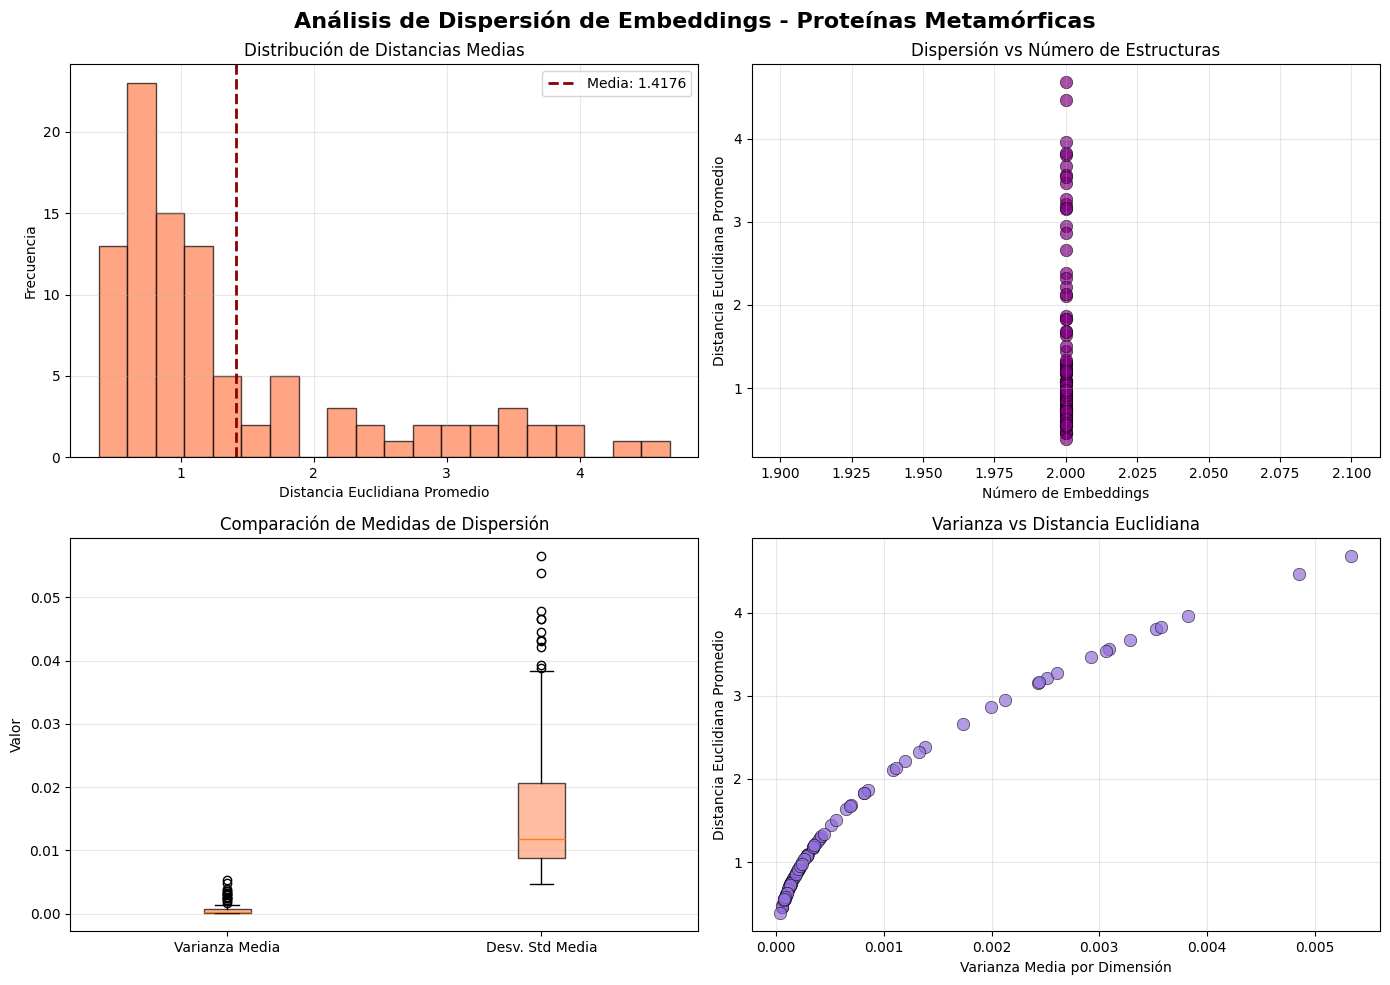


✅ Gráficos guardados en 'embeddings_dispersiones_metamorf_analysis.png'


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular dispersión media global para metamórficas
print("=" * 60)
print("ESTADÍSTICAS GLOBALES DE DISPERSIÓN - METAMÓRFICAS")
print("=" * 60)

dispersión_media_metamorf = df_dispersiones_metamorf['dist_mean'].mean()
dispersión_std_metamorf = df_dispersiones_metamorf['dist_mean'].std()

print(f"\nDistancia euclidiana promedio entre embeddings:")
print(f"  Media: {dispersión_media_metamorf:.4f}")
print(f"  Desviación estándar: {dispersión_std_metamorf:.4f}")
print(f"  Mín: {df_dispersiones_metamorf['dist_mean'].min():.4f}")
print(f"  Máx: {df_dispersiones_metamorf['dist_mean'].max():.4f}")

print(f"\nVarianza promedio por dimensión:")
print(f"  Media: {df_dispersiones_metamorf['var_mean'].mean():.6f}")
print(f"  Desviación estándar: {df_dispersiones_metamorf['var_mean'].std():.6f}")

print(f"\nCoeficiente de variación promedio:")
print(f"  Media: {df_dispersiones_metamorf['cv_mean'].mean():.4f}")
print(f"  Desviación estándar: {df_dispersiones_metamorf['cv_mean'].std():.4f}")

# Crear figura con múltiples gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de Dispersión de Embeddings - Proteínas Metamórficas', fontsize=16, fontweight='bold')

# Gráfico 1: Histograma de distancias medias
axes[0, 0].hist(df_dispersiones_metamorf['dist_mean'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(dispersión_media_metamorf, color='darkred', linestyle='--', linewidth=2, label=f'Media: {dispersión_media_metamorf:.4f}')
axes[0, 0].set_xlabel('Distancia Euclidiana Promedio')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Distancias Medias')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Gráfico 2: Scatter plot - Distancia media vs número de embeddings
axes[0, 1].scatter(df_dispersiones_metamorf['num_embeddings'], df_dispersiones_metamorf['dist_mean'], 
                   alpha=0.7, s=80, color='purple', edgecolor='black', linewidth=0.5)
axes[0, 1].set_xlabel('Número de Embeddings')
axes[0, 1].set_ylabel('Distancia Euclidiana Promedio')
axes[0, 1].set_title('Dispersión vs Número de Estructuras')
axes[0, 1].grid(alpha=0.3)

# Gráfico 3: Box plot de variancias
axes[1, 0].boxplot([df_dispersiones_metamorf['var_mean'], df_dispersiones_metamorf['std_mean']], 
                    labels=['Varianza Media', 'Desv. Std Media'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightsalmon', alpha=0.7))
axes[1, 0].set_ylabel('Valor')
axes[1, 0].set_title('Comparación de Medidas de Dispersión')
axes[1, 0].grid(alpha=0.3, axis='y')

# Gráfico 4: Scatter - Varianza vs Distancia
axes[1, 1].scatter(df_dispersiones_metamorf['var_mean'], df_dispersiones_metamorf['dist_mean'], 
                   alpha=0.7, s=80, color='mediumpurple', edgecolor='black', linewidth=0.5)
axes[1, 1].set_xlabel('Varianza Media por Dimensión')
axes[1, 1].set_ylabel('Distancia Euclidiana Promedio')
axes[1, 1].set_title('Varianza vs Distancia Euclidiana')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('embeddings_dispersiones_metamorf_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Gráficos guardados en 'embeddings_dispersiones_metamorf_analysis.png'")
